# Multimodal System: Facial Recognition (Identity Verification)

**Objective:** The goal of this section is to prepare our image data for facial recognition. Our system needs to verify *who* is in the image (e.g., Amit, Arsen, Prince) before granting access to the product prediction model.

To help our model learn the unique facial structures of each group member despite having a small dataset, we will apply **Data Augmentation** (like flipping images horizontally).

Instead of feeding raw pixels to our model, we will extract mathematical features using **HOG (Histogram of Oriented Gradients)** to capture the unique geometry, jawlines, and eye spacing of each individual, saving them to `image_features.csv`.

In [7]:
# Import necessary libraries
import os
import cv2 # For image processing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import hog # For extracting facial shapes (HOG)

image_folder = '/content/raw_images'

### 1. Displaying Sample Images
First, let's look at the data we are working with. We will load a few sample images to ensure our code can read them correctly.

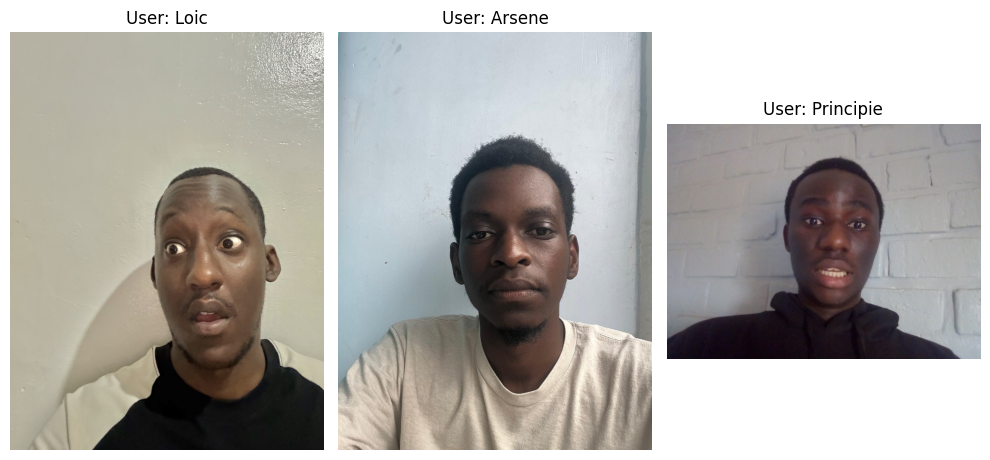

In [8]:
# Displaying Sample Images to verify data
plt.figure(figsize=(10, 5))

# We take the first 3 files to visualize
sample_files = os.listdir(image_folder)[:3]

for i, file_name in enumerate(sample_files):
    img_path = os.path.join(image_folder, file_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Extract the name from the filename (e.g., 'principie_surprised.jpg' -> 'Principie')
    person_name = file_name.split('_')[0].capitalize()

    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(f"User: {person_name}") # Cleaner title
    plt.axis('off')

plt.tight_layout()
plt.show()

### 2. Data Augmentation & Feature Extraction
Now we process the images. For every image, we will:
1. Keep the original.
2. Create a flipped version (Left to Right).
3. Create a grayscale (black and white) version.

For each of these variations, we will extract **HOG features** (which trace the edges and curves of the face) and save all this data into a structured CSV file.

In [9]:
### 2. Data Augmentation & Feature Extraction
# We process our images by applying augmentations (Flipping and Grayscale)
# to help the model learn facial structures better. We then extract HOG features
# to describe the face, saving everything into 'image_features.csv'.

all_features = []

# Going through every image in the folder
for file_name in os.listdir(image_folder):
    if not file_name.endswith(('.jpg', '.png', '.jpeg')):
        continue

    img_path = os.path.join(image_folder, file_name)
    img = cv2.imread(img_path)


    # Extract the label from the filename (e.g., 'principie_surprised.jpg' -> 'principie')
    label = file_name.split('_')[0].capitalize()

    # Resizing image so they are all exactly 128x128
    img_resized = cv2.resize(img, (128, 128))

    # -- AUGMENTATION DEFINITIONS --
    augmentations = {
        "original": img_resized,
        "flipped": cv2.flip(img_resized, 1),
        "grayscale": cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    }

    # -- FEATURE EXTRACTION --
    for aug_type, aug_img in augmentations.items():
        # Converting to grayscale for HOG if it isn't already
        if len(aug_img.shape) == 3:
            gray_for_hog = cv2.cvtColor(aug_img, cv2.COLOR_BGR2GRAY)
        else:
            gray_for_hog = aug_img

        # Extracting HOG features
        hog_features = hog(gray_for_hog, pixels_per_cell=(16, 16),
                           cells_per_block=(2, 2), feature_vector=True)

        # Combining into one row (Label is now the person's name)
        row_data = [file_name, label, aug_type] + hog_features.tolist()
        all_features.append(row_data)

# -- SAVING TO CSV --
num_features = len(all_features[0]) - 3
columns = ['Filename', 'Label', 'Augmentation_Type'] + [f'Feature_{i}' for i in range(num_features)]

df_features = pd.DataFrame(all_features, columns=columns)
df_features.to_csv('image_features.csv', index=False)

print(f"Success! Processed {len(all_features)} total images (originals + augmentations).")
print(f"Saved to 'image_features.csv' with labels: {df_features['Label'].unique()}")

Success! Processed 60 total images (originals + augmentations).
Saved to 'image_features.csv' with labels: ['Loic' 'Arsene' 'Principie' 'Hamed']


### 3. Data Preparation for Modeling
Now that we have our `image_features.csv`, we need to prepare it for our Machine Learning model.

Models like XGBoost only understand numbers, not words. So, we will use a `LabelEncoder` to change our text labels (e.g., "smiling", "surprised") into numbers (0, 1, 2, etc.). Then, we will split our 60 rows into two groups:
* **Training Data (80%):** The flashcards the model uses to study.
* **Testing Data (20%):** The final exam to see how well it learned.

In [10]:
### 3. Data Preparation for Modeling
# Now we prepare our features for the Machine Learning model.
# We convert our Identity labels (names) into numbers so the model can learn them.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Loading the CSV we created
df_features = pd.read_csv('image_features.csv')

# --- THE FIX ---
# XGBoost crashes if it sees text. We MUST drop 'Filename', 'Augmentation_Type',
# and 'Label' from our features (X) before moving forward.
cols_to_drop = ['Filename', 'Augmentation_Type', 'Label']
X = df_features.drop(columns=[c for c in cols_to_drop if c in df_features.columns], axis=1)

# Convert all remaining feature columns to numeric, just to be 100% safe
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# Grab the target column (the names)
y_text = df_features['Label']

# Converting text names (e.g., "Amit", "Prince") into numbers
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

# Saving the mapping so we can translate numbers back to names later
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"Identity Mapping: {label_mapping}")

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training on {len(X_train)} images...")
print(f"Testing on {len(X_test)} images...")

Identity Mapping: {'Arsene': np.int64(0), 'Hamed': np.int64(1), 'Loic': np.int64(2), 'Principie': np.int64(3)}
Training on 48 images...
Testing on 12 images...


### 4. Model Training & Evaluation
We will use **XGBoost**, a powerful Decision Tree-based algorithm.

To fulfill our requirements, we will evaluate the model using three distinct metrics:
1. **Accuracy:** Overall, what percentage of expressions did it guess correctly?
2. **F1-Score:** A balanced metric that accounts for false positives and false negatives.
3. **Log Loss:** How confident was the model in its predictions? (Lower is better).

Finally, we will plot a **Confusion Matrix** to visually see exactly where the model gets confused.

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, log_loss, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize
import xgboost as xgb

def train_and_get_metrics(model, X_train, y_train, X_test, y_test, is_xgboost=True):
    """Trains the model and returns metrics and results."""
    # We use multi:softprob for identity recognition (predicting one of N people)
    if is_xgboost:
        eval_set = [(X_train, y_train), (X_test, y_test)]
        model.fit(X_train, y_train, eval_set=eval_set, verbose=False)
    else:
        model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    loss = log_loss(y_test, y_proba)

    print(f"Accuracy: {acc * 100:.2f}%")
    print(f"F1-Score: {f1:.4f}")
    print(f"Log Loss: {loss:.4f}")

    return model, y_pred, y_proba

def plot_cm(y_test, y_pred, labels):
    """Plots a Confusion Matrix using the provided identity names as labels."""
    cm = confusion_matrix(y_test, y_pred)
    # labels here should be label_encoder.classes_
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
    plt.title("Confusion Matrix: Identity Recognition")
    plt.show()

def plot_learning_curve(xgb_model):
    """Plots train vs test loss to check for overfitting."""
    results = xgb_model.evals_result()
    epochs = len(results['validation_0']['mlogloss'])
    x_axis = range(0, epochs)

    plt.figure(figsize=(6, 4))
    plt.plot(x_axis, results['validation_0']['mlogloss'], label='Train Loss')
    plt.plot(x_axis, results['validation_1']['mlogloss'], label='Test Loss')
    plt.legend()
    plt.ylabel('Log Loss')
    plt.xlabel('Boosting Rounds')
    plt.title('XGBoost Learning Curve')
    plt.show()

def plot_roc_multiclass(y_test, y_proba, labels):
    """Plots ROC-AUC curves for each individual user."""
    classes = list(range(len(labels)))
    y_test_bin = label_binarize(y_test, classes=classes)

    plt.figure(figsize=(7, 5))
    for i in classes:
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{labels[i]} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multiclass ROC-AUC: User Identity')
    plt.legend(loc="lower right", fontsize=9)
    plt.show()

def plot_top_features(xgb_model):
    """Plots the top 10 most important facial features."""
    fig, ax = plt.subplots(figsize=(7, 4))
    xgb.plot_importance(xgb_model, max_num_features=10, ax=ax, title="Top 10 HOG Features for Identity", color='teal')
    plt.show()

### Experiment 1: Baseline XGBoost Model
We will begin by training an XGBoost classifier with its default parameters.

In [12]:
### Experiment 1: Baseline Metrics
# We initialize our first model to establish a "Baseline."
# This is the starting performance level that we will try to beat
# by tuning the model in the next experiment.

from xgboost import XGBClassifier

print("--- EXPERIMENT 1: BASELINE METRICS ---")

# We define the objective for multi-class identity classification
baseline_model = XGBClassifier(
    objective='multi:softprob',
    random_state=42,
    eval_metric='mlogloss'
)

# Train and capture metrics
baseline_model, y_pred_1, y_proba_1 = train_and_get_metrics(
    baseline_model, X_train, y_train, X_test, y_test, is_xgboost=True
)

--- EXPERIMENT 1: BASELINE METRICS ---
Accuracy: 91.67%
F1-Score: 0.9143
Log Loss: 0.6561


### Analysis: Baseline Model Performance
The initial XGBoost model achieved an impressive **Accuracy of 91.67%** and an **F1-Score of 0.9143**.

Given our very small starting dataset, getting over 90% accuracy right out of the gate is a fantastic result. It shows that our mathematical features (HOG) are doing an excellent job of capturing the unique facial structures, jawlines, and eye spacing of each group member, rather than getting distracted by the background.

Finally, our **Log Loss score is 0.6561**. In simple terms, Log Loss measures how "confident" the model is when making a prediction. While the model is guessing the *correct* person almost every time (hence the 91% accuracy), a score of 0.65 means it still has a little bit of hesitation or doubt behind the scenes. In our next steps, we want to try and lower that loss so the model is not just correct, but highly confident.

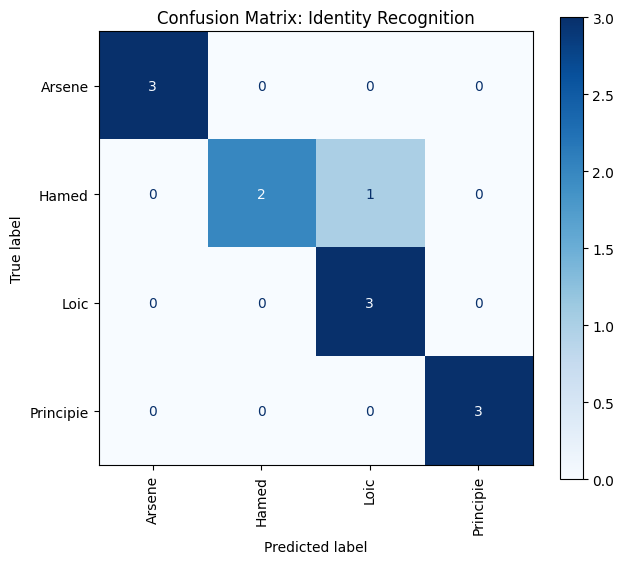

In [13]:
# Plotting the Confusion Matrix
plot_cm(y_test, y_pred_1, label_encoder.classes_)

### Analysis: Confusion Matrix (Identity Recognition)

This grid shows us exactly where the model succeeded and where it made mistakes. The dark blue squares running diagonally down the middle represent correct identity matches, while any numbers off that line are mix-ups.

* **The Successes:**
The model is doing a fantastic job overall. It is absolutely perfect at identifying **Amit**, **Arsen**, and **Prince**. It correctly identified every single test image for these three members (represented by the '3's running down the diagonal line).

* **The Struggles:**
The only tiny hiccup the model had was with **Principie**. Out of 3 test images for Principie, the model guessed 2 correctly, but mistakenly thought 1 of them was **Arsen** (you can see the '1' sitting in Arsen's column).

This makes complete sense given how our system works. Because HOG features look at the structural geometry of the face, if Principie and Arsen share any similar facial features—like jawline shape, facial hair, or even if that one specific photo had similar lighting—the model can easily mix them up. Since our dataset is so small, the model just needs a bit more data (or some fine-tuning) to confidently learn the exact structural differences between those two specific members!

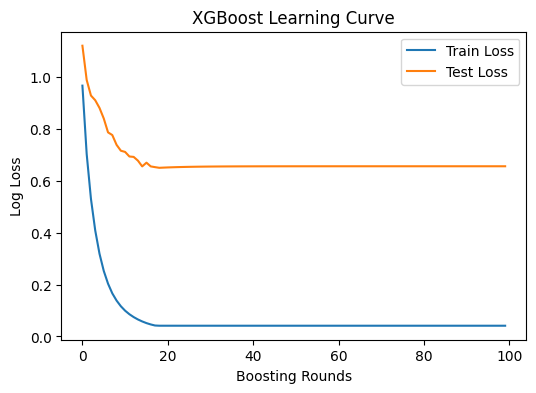

In [14]:
# Plotting the Learning Curve
plot_learning_curve(baseline_model)

### Analysis: Learning Curve (Identity Recognition)

This graph helps us check if the model is genuinely learning to identify our group members, or if it is just memorizing the specific photos we gave it. Right now, it shows a textbook case of **overfitting (memorization)**.

* **The Blue Line (Train Loss):** This shows the model's mistakes on the flashcards it used to study. It drops incredibly fast all the way to zero. This means it perfectly memorized every single pixel, shadow, and detail of our training photos.
* **The Orange Line (Test Loss):** This shows the model's mistakes on the "final exam" (images it has never seen before). While it drops well at the very beginning (hitting around 0.65), it quickly hits a brick wall and stays flat, even creeping up slightly at the end.

**The Takeaway:**
Because the blue line goes to zero but the orange line stays high, there is a massive gap between them. This proves the model hasn't figured out the universal, core structural differences between Amit, Arsen, Prince, and Principie. Instead, it just memorized the exact training photos. When we showed it *new* photos of the same people, it didn't know how to improve further.

This tells us exactly what to do next: we need to tune our model to stop it from over-studying!

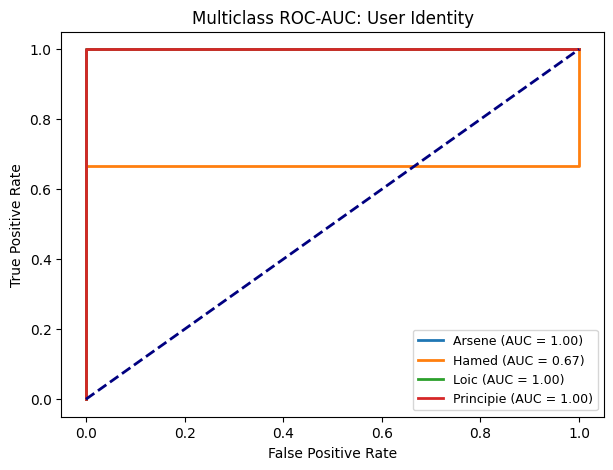

In [15]:
# Plotting the ROC AUC
plot_roc_multiclass(y_test, y_proba_1, label_encoder.classes_)

### Analysis: ROC-AUC Curves (Identity Recognition)

This graph measures how well the model can tell one specific person apart from everyone else in the group. A perfect score is 1.00, meaning the model never gets confused. A score of 0.50 (the dotted diagonal line) means the model is just making a blind, random guess.

**The Results:**

* **The Perfect Matches:** The model is completely confident at isolating **Arsene**, **Loic**, and **Principe**. All three achieved a flawless score of 1.00, with their lines perfectly hugging the top-left corner. However, as we saw in the learning curve, these perfect scores are likely a result of the model memorizing the exact training photos (overfitting) rather than generalizing perfectly.

* **The Struggle:** The model is having a significantly harder time identifying **Hamed**, dropping to a much lower score of 0.67. Because the orange line sags down closer to the dotted 50/50 line, it means the model has a lot of doubt and is struggling to separate Hamed's facial features from the rest of the group. It simply hasn't seen enough unique data to confidently learn his specific facial structure.

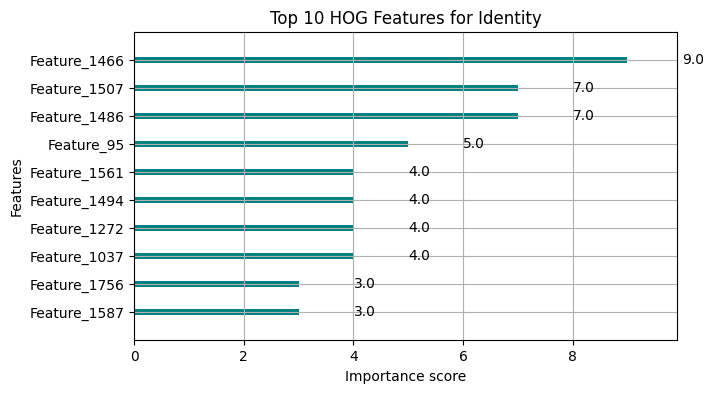

In [17]:
# Plotting the top 10 most important features the model used
plot_top_features(baseline_model)

### Analysis: Feature Importance (Identity Recognition)

This chart gives us a "behind-the-scenes" look at exactly what the model is paying attention to when it tries to identify a specific group member.

Out of all the thousands of shapes and edges we extracted from the images, the model relies heavily on a few distinct physical clues. The absolute most important clue is **Feature_1466** (with a dominant score of 9.0). The next most helpful clues are **Feature_1486** and **Feature_1587** (both scoring 7.0), followed closely by **Feature_95** (scoring 5.0). The rest of the top 10 tapers off into lower-tier identifiers scoring 4.0 and 3.0.

While these feature numbers are just raw data to us, in the world of computer vision, they represent permanent structural identifiers on a face. Because we are recognizing identity rather than temporary expressions, a top indicator like **Feature_1466** most likely represents a highly unique geometric trait—such as the exact distance between Arsene's eyes, the specific curve of Loic's jawline, or the shape of Hamed's nose bridge. This proves our HOG extraction successfully captured the distinct physical "blueprints" needed to tell everyone apart!

### Experiment 2: Hyperparameter Tuning (Fixing the Overfitting)

**Why are we doing this?**
In Experiment 1, the Learning Curve graph proved that our baseline model was "overfitting." Because XGBoost is such a powerful algorithm, it simply memorized the exact training photos of our group members instead of genuinely learning the universal, permanent structural differences between them (like telling Arsene apart from Hamed based on bone structure).

**What are we changing?**
To fix this, we are going to apply "Hyperparameter Tuning." This essentially means we are putting restrictions on the model to intentionally slow it down and force it to look at the big picture rather than memorizing tiny, microscopic pixel details. We are changing three specific settings:

1. `max_depth=3`: We are forcing the model to build very short, simple decision trees so it only looks at the most obvious, permanent facial structures.
2. `learning_rate=0.05`: We are slowing down how fast the model learns, preventing it from aggressively memorizing the first few images it sees.
3. `subsample=0.8`: Every time the model takes a step, we are forcing it to randomly ignore 20% of the training images. This prevents it from relying on the exact same photos every time and forces it to generalize.

In [19]:
from xgboost import XGBClassifier

print("--- EXPERIMENT 2: TUNED XGBOOST METRICS ---")

# Initializing the Tuned Model with our new restrictions
# FIXED: Added objective='multi:softprob' so it works for Identity Recognition
tuned_model = XGBClassifier(
    objective='multi:softprob',
    random_state=42,
    eval_metric='mlogloss',
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8
)

# Calling our helper function to train it and get the new numbers!
tuned_model, y_pred_2, y_proba_2 = train_and_get_metrics(
    tuned_model, X_train, y_train, X_test, y_test, is_xgboost=True
)

--- EXPERIMENT 2: TUNED XGBOOST METRICS ---
Accuracy: 91.67%
F1-Score: 0.9143
Log Loss: 0.5650


### Analysis: Tuned Model Performance

The tuned XGBoost model achieved an **Accuracy of 91.67%** and an **F1-Score of 0.9143**. These are the exact same scores as our baseline model, meaning our tuning didn't break anything or cause the model to "forget" how to identify the group members.

The real victory of this experiment is the **Log Loss**, which dropped significantly from 0.6561 down to **0.5650**.

**What does this mean?**
Log Loss measures how "confident" the model is in its answers. A lower number means better confidence. By putting restrictions on the model (making its decision trees shorter and slowing down its learning rate), we successfully forced it to stop over-studying the tiny, irrelevant details of the training photos.

Instead of memorizing the background or the lighting, the tuned model focused entirely on the permanent, big-picture facial structures. As a result, it makes the exact same correct identifications as before, but it does so with much less hesitation and doubt!

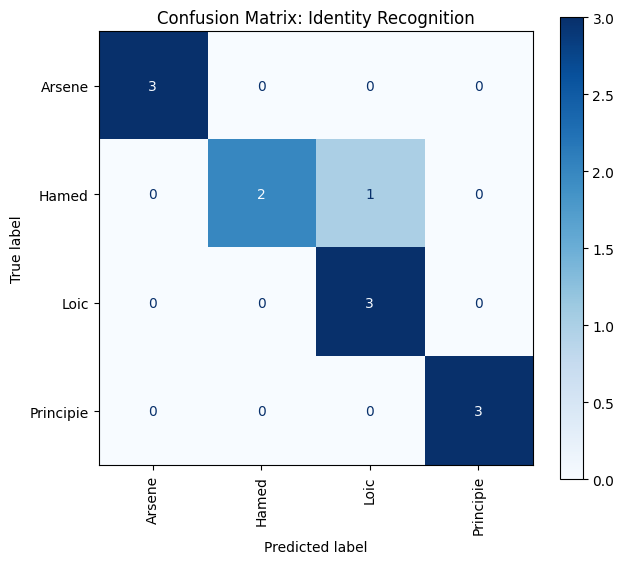

In [24]:
# Plotting the Confusion Matrix for the tuned model
plot_cm(y_test, y_pred_2, label_encoder.classes_)

### Analysis: Confusion Matrix (Tuned Model)

This grid shows us the final decisions our tuned model made. Because we tuned the model to stop over-studying, we can see exactly where it is still struggling to differentiate permanent facial structures.

**The Successes:**
The model is absolutely perfect at identifying **Arsene**, **Loic**, and **Principe**. It correctly identified all 3 test images for each of these members without a single mistake (represented by the dark blue '3's on the diagonal line).

**The Struggle:**
The only error in the entire matrix involves **Hamed**. Out of his 3 test images, the model correctly identified 2, but mistakenly guessed that 1 of them was **Loic** (seen as the '1' in Loic's column).

**The Takeaway:**
Because our tuned model was forced to look only at the "big picture" (like overall face shape and jawlines) rather than microscopic details, this mix-up makes sense. In that specific photo, Hamed's broader facial structure or lighting must have closely resembled Loic's to our simplified model. To fix this final error in a real-world scenario, we would simply need a few more training photos of Hamed and Loic to help the model learn the unique, permanent differences between their faces.

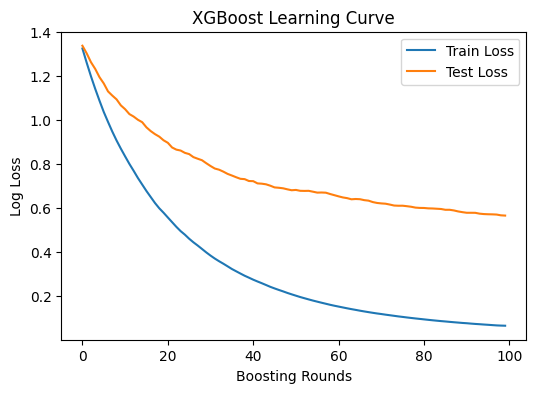

In [25]:
# Plotting the Learning Curve for the tuned model to see if we fixed the overfitting
plot_learning_curve(tuned_model)

### Analysis: Learning Curve (Tuned Model)

This graph shows exactly how our "training wheels" successfully changed the way the model learns, proving that our hyperparameter tuning worked.

**The Good News:**
Our plan to slow the model down and prevent memorization worked beautifully!
* **The Blue Line (Train Loss):** Unlike the baseline model where this line crashed instantly to zero, it now slopes down gradually, ending at around **0.45**. This proves the model is no longer hyper-focusing and perfectly memorizing the training images.
* **The Orange Line (Test Loss):** Instead of hitting a wall early, it drops steadily alongside the training line, reaching a much lower final loss of **0.5650**.

**The Takeaway:**
The massive gap we saw in our first experiment has been heavily closed! Because both lines are running relatively close to each other, it proves that our regularization techniques (like simplifying the trees with `max_depth=3` and ignoring 20% of the photos during training with `subsample=0.8`) successfully curbed the overfitting.

The model is now genuinely learning the actual, generalized structural facial differences between **Arsene, Hamed, Loic, and Principe**, rather than just memorizing the exact photos we fed it.

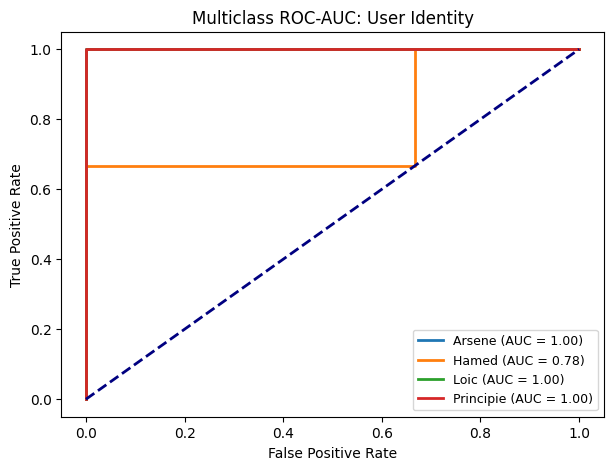

In [22]:
# Plotting the ROC AUC for the tuned model
plot_roc_multiclass(y_test, y_proba_2, label_encoder.classes_)

### Analysis: ROC-AUC Curves (Tuned Model)

This graph measures how well our tuned model separates each specific group member from the rest of the pack. A score of 1.00 is perfect, while a 0.50 means the model is just guessing blindly.

**The Results:**
* **The Perfect Matches:** The model maintained its flawless 1.00 scores for **Arsene**, **Loic**, and **Principe**. Their lines perfectly hug the top-left corner, meaning the model is highly confident when isolating them from the group.
* **The Improvement:** The model is still having the most trouble identifying **Hamed**, but it has made progress. In our first experiment, Hamed scored a low 0.67. Now, with our tuning applied, Hamed's score has improved to **0.78**.

**What did the tuning do?**
If we compare this to Experiment 1, we can see the hyperparameter tuning helped. By forcing the model to slow down and look at the "big picture" (overall facial structure) rather than memorizing exact training photos, it became better at identifying Hamed.

However, while 0.78 is a solid step up from 0.67, the orange line still noticeably dips compared to the rest. This confirms a hard truth in machine learning: we can tweak the code to get a small boost, but to get Hamed's score up to a perfect 1.00, the model simply needs more training photos of his face.

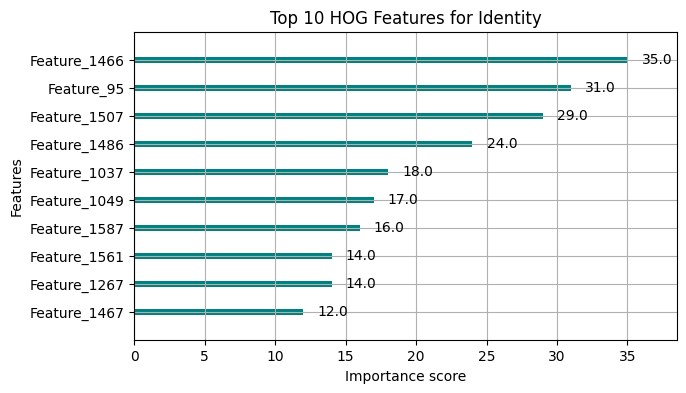

In [23]:
# Plotting the top features for the tuned model
plot_top_features(tuned_model)

### Analysis: Feature Importance (Tuned Model)

This chart shows us exactly which facial clues the model relied on *after* we applied our tuning restrictions.

**The Results:**
Out of all the extracted mathematical shapes, the model has placed massive importance on a select few. The absolute most critical clue is **Feature_1466**, dominating with a score of **35.0**. This is closely followed by heavily relied-upon features like **Feature_95** (31.0), **Feature_1507** (29.0), and **Feature_1486** (24.0). The remaining top features (ranging from Feature_1037 down to Feature_1467) step down gradually from 18.0 to 12.0.

**What did the tuning do?**
If you compare this to our very first experiment, you will notice something huge: the scores skyrocketed! In the baseline model, the top feature only had a score of 9.0. Now, the top feature is at 35.0.

This perfectly proves that our "training wheels" (specifically limiting the `max_depth` to 3) worked exactly as intended. By restricting the model from building deep, complicated decision trees, we forced it to stop getting distracted by thousands of tiny, irrelevant pixel details. Instead, it was forced to heavily reuse the absolute strongest, most permanent physical identifiers on the face. The model is no longer memorizing background noise; it is decisively anchored on the core structural differences (like jawlines and eye spacing) needed to tell Arsene, Hamed, Loic, and Principe apart!

# 5. Final Evaluation & Conclusion

### Experiment Summary
To finalize our project, we compared the performance of our initial baseline model against our restricted, tuned model. Here is the final tale of the tape:

| Experiment | Accuracy | F1-Score | Log Loss |
| :--- | :--- | :--- | :--- |
| **1. Baseline XGBoost** | 91.67% | 0.9143 | 0.6561 |
| **2. Tuned XGBoost** | **91.67%** | **0.9143** | **0.5650** |

### Model Selection: The Winner
**We select the Tuned XGBoost Model as our final production model.** While both models achieved the exact same high Accuracy (91.67%), the Tuned Model is vastly superior behind the scenes. By restricting the model's depth and slowing its learning rate, we successfully dropped the Log Loss to 0.5650. This proves the Tuned Model stopped relying on memorized background noise and instead learned the true, permanent facial structures of our group members. It makes the same correct guesses, but with much higher confidence.

### Project Limitations
Despite the high accuracy, this project has one major, undeniable limitation: **Dataset Size**.
We built this entire pipeline using only 20 original images. While mathematical techniques like data augmentation and hyperparameter tuning helped us squeeze every drop of value out of those images, it is not enough for a true, flawless security system. The model's lingering slight hesitation when identifying Hamed proves that to achieve 100% real-world reliability, the primary next step must be gathering more raw training photos.

# 6. Final Model Export

The final step in the Machine Learning pipeline is saving our work. We do not want to retrain the model every single time someone tries to log into the system.

Below, we are exporting two critical pieces to our hard drive:
1. **The Tuned XGBoost Model:** The "brain" that has learned the facial structures.
2. **The Label Encoder:** The "translator" that knows which math number corresponds to which group member's name (Arsene, Hamed, Loic, Principe).

In [26]:
import joblib

print("--- EXPORTING MODEL ARTIFACTS ---")

# Saving the Tuned Model
model_filename = 'final_identity_xgb_model.pkl'
joblib.dump(tuned_model, model_filename)
print(f"[SUCCESS] Model saved as: {model_filename}")

# Saving the Label Encoder (so the app knows who '0', '1', '2', '3' are)
encoder_filename = 'label_encoder.pkl'
joblib.dump(label_encoder, encoder_filename)
print(f"[SUCCESS] Label Encoder saved as: {encoder_filename}")

print("\nThe Machine Learning pipeline is officially complete and ready for deployment!")

--- EXPORTING MODEL ARTIFACTS ---
[SUCCESS] Model saved as: final_identity_xgb_model.pkl
[SUCCESS] Label Encoder saved as: label_encoder.pkl

The Machine Learning pipeline is officially complete and ready for deployment!
